<a href="https://colab.research.google.com/github/WaffleCollege/a0i/blob/main/Copy_of_10_%E3%82%84%E3%81%A3%E3%81%A6%E3%81%BF%E3%82%88%E3%81%86_Answer_Flask_with_ORM_for_Blog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
#@title #1.　ngrokのauth_tokeを設定して前回の内容を実行[事前準備、設定]
# 1,2 Flask, pyngrokのインストール
!pip install flask pyngrok
#  必要なモジュールのimport
import os
# flaskからFlaskクラスをインポート
from flask import Flask
# pyngrokからngrokモジュールとconfモジュールをインポート
from pyngrok import ngrok, conf
# 設定
# ngrokトークンを設定
conf.get_default().auth_token = "2mepvEWayME5JKd4dEaFPX6DzE2_6wDZD6nXcaHiX9KRsw1GN" #ここに自分のNgrokトークンを入れてください！！！！！

# Googleドライブのマウント
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [73]:
# @title 1-2 Flask-SQLAlchemyのインストール
!pip install Flask-SQLAlchemy

# 3. [やってみよう]テンプレートの更新


(下記最新ver.にしておく）
*   home.html
*   blogs.html
*   blog.html

（新規追加）Comment用
* comments.html ... コメントを登録するフォームがある + コメントがすべて一覧で表示される
* comment.html ... 一つの登録済みコメントを更新するフォームがある　＋　削除ボタン（実はフォーム）がある

# 3-1. drive/My Drive/flask_blog/templates/home.html

```
<!DOCTYPE html>
<html>
  <link rel="stylesheet" href="{{ url_for('static', filename='css/style.css')}}">
<head>
</head>
<body>
    <header>
      <h1>ミニブログをつくってみよう !</h1>
    </header>
    <a href="{{ url_for('blog_index')}}">ブログ</a>
</body>
</html>
```


# 3-2. drive/My Drive/flask_blog/templates/blogs.htmlを更新

blogsをBlogオブジェクト(あとで設定）の形で読み出す

```
<!DOCTYPE html>
<html>
  <link rel="stylesheet" href="{{ url_for('static', filename='css/style.css')}}">
<head>
</head>
<body>
    <header>
      <h1>ミニブログを作ってみよう</h1>
    </header>
    <div>
    {% with messages = get_flashed_messages() %}
      {% if messages %}
      <ul class=flashes>
      {% for message in messages %}
        <li>{{ message }}</li>
      {% endfor %}
       </ul>
       {% endif %}
     {% endwith %}
    </div>
    <div>
    <form
    action="{{url_for('blog_create')}}"
    method="POST"
    novalidate="novalidate"
  >
    <p>
      <label for="title">タイトル：</label><input type="text" name="title" value="{{blog.title or request.form["title"]}}" />
    </p>
    <p>
      <label for="user_name">投稿者名：</label><input type="text" name="user_name" value="{{blog.user_name or request.form["user_name"]}}" />
    </p>
    <p>
      <label for="body">内容：</label><textarea name="body" cols="40" rows="10">{{blog.body or request.form["body"]}}</textarea>
    </p>
    <p><button type="submit">送る</button></p>
  </form>

  </div>

  <div>
    <ul>
      {% for blog in blogs %} <!-- ループさせてそれぞれ要素を取り出す -->
      <li><a href="{{url_for('get_blog', id=blog.id)}}">{{ blog.title }}</a></li> <!-- ブログ編集画面へのリンク -->
       {% endfor %}
    </ul>
  </div>
</body>
</html>
```





# 3-3. drive/My Drive/flask_blog/templates/blog.htmlを新規作成

同じくBlogオブジェクトを扱う形に変更

```
<!DOCTYPE html>
<html>
  <link rel="stylesheet" href="{{ url_for('static', filename='css/style.css')}}">
<head>
</head>
<body>
    <header>
      <h1>ミニブログを作ってみよう:ブログ詳細画面</h1>
    </header>
    <div>
    {% with messages = get_flashed_messages() %}
      {% if messages %}
      <ul class=flashes>
      {% for message in messages %}
        <li>{{ message }}</li>
      {% endfor %}
       </ul>
       {% endif %}
     {% endwith %}
    </div>
    <div>
    <form
    action="{{url_for('update_blog', id=blog.id)}}"
    method="post"
    novalidate="novalidate"
  >
    <input type="hidden" name="_method" value="PATCH">
    <p>
      <label for="title">タイトル：</label><input type="text" name="title" value={{blog.title}} />
    </p>
    <p>
      <label for="user_name">投稿者名：</label><input type="text" name="user_name" value={{blog.user_name}} />
    </p>
    <p>
      <label for="body">内容：</label><textarea name="body" cols="40" rows="10"  >{{blog.body}}</textarea>
    </p>
    <p><button type="submit">送る</button></p>
  </form>

  </div>
    <form
    action="{{url_for('update_blog', id=blog.id)}}"
    method="post"
    novalidate="novalidate"
  >
  　<input type="hidden" name="_method" value="DELETE">
   <p><button type="submit">削除</button></p>
  </form>
</body>
</html>
```

ファイルがこの状態になっているはず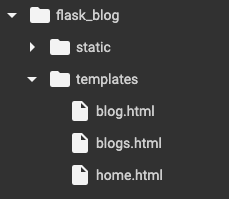

In [74]:
#@title　#4.アプリケーションを初期化する

from flask import g, render_template


# テンプレートと静的ファイルの置き場所を定数に代入
TEMPLATE_PATH = 'drive/My Drive/flask_blog/templates'
STATIC_PATH = 'drive/My Drive/flask_blog/static'
# Flaskのインスタンスを作るときにそれを利用してファイルパスを設定する
app = Flask(__name__, template_folder=TEMPLATE_PATH, static_folder=STATIC_PATH)

In [75]:
#@title　#5.Flask-SQLAlcyemyをアプリに設定をする

from flask_sqlalchemy import SQLAlchemy
from sqlalchemy.orm import DeclarativeBase

class Base(DeclarativeBase):
  pass #これは何にもしないと言う意味

# SQLAlchemyをインスタンス化
db = SQLAlchemy(model_class=Base)

# SQLiteデータベースをappに設定する
app.config["SQLALCHEMY_DATABASE_URI"] = "sqlite:///sample_db.sqlite"
#  appを拡張とともに初期化
db.init_app(app)

In [76]:
#@title　#6. Blogモデルを作る
from sqlalchemy import  DateTime, Integer, String
from sqlalchemy.orm import Mapped, mapped_column, validates

class Blog(db.Model):
    id: Mapped[int] = mapped_column(primary_key=True)
    title: Mapped[str] = mapped_column(nullable=False)
    body: Mapped[str] = mapped_column(nullable=False)
    user_name: Mapped[str] = mapped_column(nullable=False)
    created_at: Mapped[int] = db.Column(db.DateTime(timezone=True))

    # https://docs.sqlalchemy.org/en/20/orm/mapped_attributes.html#simple-validators
    @validates("title", "body", "user_name")
    def validate_existance(self, key, value):
        if not value:
            raise ValueError(key)

        return value

In [77]:
#@title　#[やってみよう]6-2. Commentモデルを作る
from sqlalchemy import  DateTime, Integer, String
from sqlalchemy.orm import Mapped, mapped_column, validates

# コメントモデルのカラム
# id int型/Primary Key
# blog_id int型/Foregin Key 参考：https://flask-sqlalchemy.readthedocs.io/en/stable/models/#defining-tables (Foregin Key設定は難しければなくてもいい)
# body str型 コメント本文
# user_name str型 コメントユーザー名
# created_at int型　投稿日時

#Commentクラスの作成
class Comment(db.Model):
  id: Mapped[int] = mapped_column(primary_key=True)
  comment_title: Mapped[str] = mapped_column(nullable=False)
  comment_body: Mapped[str] = mapped_column(nullable=False)
  comment_user_name: Mapped[str] = mapped_column(nullable=False)
  comment_created_at: Mapped[int] = db.Column(db.DateTime(timezone=True))

#エラー返す
  @validates("comment_title", "comment_body", "comment_user_name")
  def validate_existance(self, key, value):
        if not value:
            raise ValueError(key)

        return value

In [78]:
#@title #7.Blogモデル・Commentモデルをもとにテーブルを作成する

# アプリケーションが実行されるコンテキスト内で行うという指定のwith
with app.app_context():
  db.drop_all() # 今まで作成したテーブルを一度すべて消す。6でBlogモデルに変更を加えてない場合は不要
  #  テーブルを作成
  db.create_all()

 # 8.アプリケーションでデータを読み出す+テンプレートにデータを渡すプログラミング

In [79]:
#@title #8-1. ルート/, GET /blogs 一覧画面（フォーム付き）, POST /blogs データ作成機能 （前回と同じ）


from datetime import datetime, timedelta
from zoneinfo import ZoneInfo
from flask import g, render_template, redirect, url_for, request, flash, session

#セッションを設定する
app.secret_key = 'timestamp'
app.permanent_session_lifetime = timedelta(days=5)
# /（ルート）にアクセスしたら次に書く関数(home)を実行するという宣言
@app.route("/")
def home():
    return render_template('home.html')

# /blogs にHTTPメソッドがGETでアクセスしたblog_index関数を実行する
@app.get("/blogs")
def blog_index():
   #データベースからデータを引き出す（オブジェクトのリストの形で帰ってくる）
    # https://msiz07-flask-docs-ja.readthedocs.io/ja/latest/patterns/sqlalchemy.html#declarative
    # Blogモデルを使って登録済みblogオブジェクトをすべて取得
    blogs = Blog.query.all()
    # テンプレートにblogs変数を渡す
    return render_template('blogs.html', blogs = blogs, blog = Blog())

# /blogs にHTTPメソッドがPOSTでアクセスしたblog_create関数を実行する
@app.post("/blogs")
def blog_create():

    # フォームの値を取得してBlogモデルのオブジェクトをつくる
    title = request.form["title"]
    user_name = request.form["user_name"]
    body = request.form["body"]
    blog = Blog()
    try:
        blog = Blog(title = title, user_name = user_name, body = body)
        db.session.add(blog)
        db.session.commit()
    except ValueError as ve:
      flash(f"入力が不足しています#{ve}")
    except Exception as e:
       flash(f"予期せぬエラー #{e}")
    blogs =  Blog.query.all()
    # blogs.htmlテンプレートを描画
    return render_template('blogs.html', blogs = blogs, blog = blog)


In [80]:
# @title 8-2 GET /blogs/:id 更新用フォーム、Post(気持ちはpatch) /blogs/:id 更新処理

@app.get('/blogs/<string:id>')
def get_blog(id):
    # dbからURLで指定されたidのblogオブジェクトを取得　blog変数に代入
    blog = db.get_or_404(Blog, id)
    # https://flask-sqlalchemy.readthedocs.io/en/3.1.x/queries/#queries-for-views
    return render_template('blog.html', blog = blog)

@app.post('/blogs/<string:id>')
def update_blog(id):
    blog = db.get_or_404(Blog, id)

    # 更新処理の場合
    if request.form.get('_method') == 'PATCH':
        try:
            blog.title = request.form["title"]
            blog.user_name = request.form["user_name"]
            blog.body = request.form["body"]
            db.session.commit()
            flash("データを更新しました")
        except ValueError as ve:
            flash(f"入力が不足しています#{ve}")
        except Exception as e:
            flash(f"予期せぬエラー #{e}")
        # 編集画面にGETでリダイレクトする
        return redirect(url_for("get_blog", id=id))
    # 削除リクエストの場合
    elif request.form.get('_method') == 'DELETE':
        db.session.delete(blog)
        db.session.commit()
        # 一覧画面にGETでリダイレクトする
        return redirect(url_for("blog_index"))

In [81]:
#@title #[やってみよう]8-3. GET /comments 一覧画面（フォーム付き）, POST /comments データ作成機能


# /comments にHTTPメソッドがGETでアクセスしたcomment_index関数を実行する
@app.get("/comments")
def comment_index():
    #データベースからデータを引き出す（オブジェクトのリストの形で帰ってくる）
    # https://msiz07-flask-docs-ja.readthedocs.io/ja/latest/patterns/sqlalchemy.html#declarative
    # Commentモデルを使って登録済みcommentオブジェクトをすべて取得　comments変数に代入
    # ******ここを実装  8-1 blog_index() を参照*****
    comments = Comment.query.all()
    # テンプレートにcomments変数を渡す
    # ******ここを実装 8-1 blog_index() を参照*****
    return render_template('comments.html', comments = comments, comment = Comment())

# /comments にHTTPメソッドがPOSTでアクセスしたcomments_create関数を実行する
@app.post("/comments")
def comments_create():

    # フォームの値を取得してCommentモデルのオブジェクトをつくる
    # ******ここを実装 8-1 blog_create() を参照*****
    comment_title = request.form["comment_title"]
    comment_user_name = request.form["comment_user_name"]
    comment_body = request.form["comment_body"]
    comment = Comment()
    try:
        comment = Comment(comment_title = comment_title, comment_user_name = comment_user_name, comment_body = comment_body)
        db.session.add(comment)
        db.session.commit()
    except ValueError as ve:
      flash(f"入力が不足しています#{ve}")
    except Exception as e:
       flash(f"予期せぬエラー #{e}")
    comments =  Comment.query.all()

    # comments.htmlテンプレートを描画
    # ******ここを実装 8-1 blog_create() を参照*****
    return render_template('comments.html', comments = comments, comment = comment)

In [82]:
# @title #[やってみよう]8-4 GET /comments/:id 更新用フォーム、Post(気持ちはpatch) /comments/:id 更新処理

@app.get('/commetns/<string:id>')
def get_comment(id):
    # dbからURLで指定されたidのcommentオブジェクトを取得　comment変数に代入
    # ******ここを実装 8-2 get_blog() を参照*****
    comment = db.get_or_404(Comment, id)
    # https://flask-sqlalchemy.readthedocs.io/en/3.1.x/queries/#queries-for-views
    # テンプレートにcomment変数を渡す
    # ******ここを実装 8-1 blog_index() を参照*****
    return render_template('comment.html', comment = comment)

@app.post('/comments/<string:id>')
def update_comment(id):
    # dbからURLで指定されたidのcommentオブジェクトを取得　comment変数に代入
    # ******ここを実装 8-2 update_blog() を参照*****
    comment = db.get_or_404(Comment, id)
    # 更新処理の場合
    if request.form.get('_method') == 'PATCH':
       # ******ここを実装 8-2 update_blog() を参照*****
       try:
            comment.comment_title = request.form["comment_title"]
            comment.user_name = request.form["comment_user_name"]
            comment.body = request.form["comment_body"]
            db.session.commit()
            flash("データを更新しました")
       except ValueError as ve:
            flash(f"入力が不足しています#{ve}")
       except Exception as e:
            flash(f"予期せぬエラー #{e}")
        # 編集画面にGETでリダイレクトする
       return redirect(url_for("get_comment", id=id))
    # 削除リクエストの場合
    elif request.form.get('_method') == 'DELETE':
      # ******ここを実装 8-2 update_blog() を参照*****
       db.session.delete(comment)
       db.session.commit()
       return redirect(url_for("comment_index"))

In [83]:
#@title #9.アプリケーションを立ち上げる

if __name__ == "__main__":
    public_url = ngrok.connect(5000)
    print(f"ngrok URL: {public_url}")
    app.run(port=5000)

ngrok URL: NgrokTunnel: "https://2004-130-211-249-200.ngrok-free.app" -> "http://localhost:5000"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:35] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:35] "GET /static/css/style.css HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:36] "GET /favicon.ico HTTP/1.1" 404 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:44] "GET /comments HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:44] "GET /static/css/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:55] "POST /comments HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:16:55] "GET /static/css/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:17:15] "GET /static/css/style.css HTTP/1.1" 304 -
INFO:werkzeug:127.0.0.1 - - [04/Nov/2024 11:17:38] "POST /comments HTTP/1.1" 200 -
INFO:werkzeug